In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import palettable, os, glob
import warnings
from scipy.stats import mannwhitneyu, ttest_ind

warnings.filterwarnings("ignore")

# List all available fonts
file_paths = glob.glob( "/home/goldpm1/miniconda3/envs/cnvpytor/lib/python3.7/site-packages/matplotlib/mpl-data/fonts/ttf/ARIAL*" )
absolute_file_paths = [os.path.abspath(file_path) for file_path in file_paths]
for absolute_file_path in absolute_file_paths:
    mpl.font_manager.fontManager.addfont( absolute_file_path )
plt.rcParams["font.family"] = 'Arial'



df_original = pd.read_csv( '/data/project/Meningioma/script/TH_Kim/01.TINC/data/01.output/TINC_OUTPUT.tsv', sep = '\t')
sample_list = [
    "190426_FFT_Tumor", "190426_PCT_Tumor", "190426_PFT_Tumor", "190426_PP_Tumor", "190426_PT_Tumor", 
    "230802_2_Tumor", "230419_Tumor", "241023_Tumor", "220930_2_Tumor", "221102_Tumor", "240403_3_Tumor", "240412_2_Tumor",  "230127_Tumor", "230526_Tumor", "190524_Tumor",  
    "240320_Tumor", "231206_Tumor", "231025_Tumor", "230323_2_Tumor", "230323_11_Tumor", "230920_Tumor", "230822_Tumor", "240325_Tumor",
    "230405_2_Tumor", "230303_1_Tumor", "231006_Tumor", "221202_Tumor",
    "221026_Tumor","241127_Tumor", "240110_Tumor", "250207_Tumor"
]# {'190426_Tumor', '230323_11_Tumor'}  이 2개가 없음
df_original = pd.read_csv( '/data/project/Meningioma/script/TH_Kim/01.TINC/data/01.output/TINC_OUTPUT.tsv', sep = '\t')
df_original = df_original  [ df_original ['Sample'].isin(sample_list) == True ]


df = pd.read_csv( '/data/project/Meningioma/script/TH_Kim/01.TINC/data/01.output/20251030_TINC_OUTPUT.tsv', sep = '\t')
sample_list = [
    "190426_FFT", "190426_PCT", "190426_PFT", "190426_PP", "190426_PT", "230802_2", "230419", "241023", "221102", "240403_3", "240412_2", "230127", "190524", "240320", "231025", "230323_2", "230323_11", "230920", "230822",
     "230405_2", "221202", "231006",
    "221026", "240110", "220930_1", "241127", "241016", "250212"
]  # 22 vs 6
sample_list = [
    "230802_2", "230419", "241023", "221102", "240403_3", "240412_2", "230127", "190524", "240320", "231025", "230920", "230822", "230405_2", "221202", "231006", "241127",
    "221026", "240110", "220930_1", "241016", "250212"
]       # Solitary만 선택 : 15 vs 5
df = df  [ df ['sample'].isin(sample_list) == True ]
df.columns = ["Sample","TIN", "Sample_Type"]


In [8]:
df_original["Sample"] = df_original["Sample"].str.replace(r'_Tumor$', '', regex=True)
df_original["Sample_Type"] = df_original["Sample_Type"].replace({"tumor_free": "meningeal_mosaicism", "infiltrated": "tumor_infiltration"})

df_original = df_original [ (df_original["Data_Type"] == "filtered3") & (df_original["CNA"] == True) & (df_original["TIN"].isna() == False) ]
df_original

# df_original["Sample"] 중 df ["Sample"]에 없는 것이 있다면, 하나씩 row를 추가해줘.  column은 ["Sample", "TIN", "Sample_Type"] 으로
missing_samples = set(df_original["Sample"]) - set(df["Sample"])

for sample in missing_samples:
    # 해당 샘플의 df_original에서의 TIN, Sample_Type 값을 찾아서 추가
    row = df_original[df_original["Sample"] == sample][["Sample", "TIN", "Sample_Type"]]
    if not row.empty:
        if row["Sample"].values[0] in sample_list:
            df = pd.concat([df, row.rename(columns={"Sample":"Sample", "TIN":"TIN", "Sample_Type":"Sample_Type"})], ignore_index=True)


df

,Sample,TIN,Sample_Type
0,190524,0.000000,meningeal_mosaicism
1,221102,0.000000,meningeal_mosaicism
2,230127,0.000898,meningeal_mosaicism
3,230405_2,0.023682,meningeal_mosaicism
4,230920,0.000456,meningeal_mosaicism
5,231025,0.002537,meningeal_mosaicism
6,240320,0.000000,meningeal_mosaicism
7,240403_3,0.000000,meningeal_mosaicism
8,241023,0.000000,meningeal_mosaicism
9,221026,0.084954,tumor_infiltration


meningeal_mosaicism
tumor_infiltration


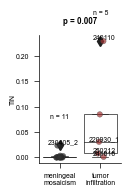

In [5]:
def DRAW_TINC_BOXPLOT ( ax, df_inside, x, y, hue, **kwargs ):
    box = sns.boxplot ( data = df_inside, x = x, y = y, hue = x, palette = kwargs["palette"], linewidth = kwargs["linewidth"], dodge = False, ax = ax )
    for i, patch in enumerate(box.patches):
        patch.set_facecolor('none')
    #sns.swarmplot ( data = df_inside, x = x, y = y, hue = x, palette = kwargs["palette"], linewidth = kwargs["linewidth"], dodge = False, ax = ax )
    sns.stripplot (  data=df_inside,  x=x, y=y, hue=hue,  palette=kwargs["palette"],  dodge=False, jitter=True,  size = kwargs.get("strip_size", 4),   marker=kwargs.get("strip_marker", "o"), linewidth=0.3, edgecolor="gray",  alpha=0.7,    ax=ax  )


    # outlier에 Sample_ID 텍스트 추가
    for i, group in enumerate(df_inside[x].unique()):
        group_data = df_inside[df_inside[x] == group]    
        # IQR 계산하여 outlier 찾기
        print (group)
        if group == "meningeal_mosaicism":
            Q1 = group_data[y].quantile(0.001)    
            Q3 = group_data[y].quantile(0.8)
        else:
            Q1 = group_data[y].quantile(0.55)
            Q3 = group_data[y].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1
        upper_bound = Q3 + 0.5 * IQR
    
        # outlier 찾기
        outliers = group_data[(group_data[y] < lower_bound) | (group_data[y] > upper_bound)]
        for idx, row in outliers.iterrows():
            ax.text(i + 0.1, row[y], row['Sample'],  fontsize = kwargs["label_fontsize"], ha='center', va='bottom')



    # 각 군의 데이터 개수를 계산하고 boxplot 위에 표시
    for j, sample_type in enumerate(df_inside[x].unique()):
        subset = df_inside[df_inside[x] == sample_type]
        count = len(subset.dropna(subset=[y]))  # NaN 값 제외한 개수
        # boxplot 위쪽에 개수 표시
        y_max = subset[y].max() if not subset[y].isna().all() else 0
        ax.text(j, y_max + 0.05, f'n = {count}', 
                ha = 'center', va = 'bottom',  fontsize=kwargs["tick_labelsize"],  fontweight = 'normal' )


    # 두 그룹이 있다고 생각하고 Mann_whitney test
    group_names = df_inside[x].unique()
    if len(group_names) == 2:
        group1 = df_inside[df_inside[x] == group_names[0]][y].dropna()
        group2 = df_inside[df_inside[x] == group_names[1]][y].dropna()
        if len(group1) > 0 and len(group2) > 0:
            stat, pval = mannwhitneyu(group1, group2, alternative="two-sided")
            y_loc = max(df_inside[y].max(), 0) + 0.03              # p값 표시 위치: y 값의 최대에서 + 0.03 정도 위에 표시 (좌우축 중앙)
            p_text = f'p = {pval:.3e}' if pval < 0.001 else f'p = {pval:.3f}'
            ax.text(0.5, y_loc, p_text, ha='center', va='bottom', fontsize=kwargs["tick_labelsize"]+1, fontweight='bold' )
            #, transform=ax.get_xaxis_transform(which='grid'), clip_on=False)




    
    ax.set_xlabel ( "", fontsize = kwargs["label_fontsize"], fontweight = "normal", labelpad = 0)
    ax.set_ylabel ( "TIN", fontsize = kwargs["label_fontsize"], fontweight = "normal", labelpad = 0)
    ax.tick_params ( axis = 'both', labelsize = kwargs["tick_labelsize"], width = kwargs["linewidth"]  )

    # ax.set_xticklabels에서 "_"를 "\n"으로 치환해서 줄바꿈으로 해줘
    new_labels = [label.get_text().replace("_", "\n") for label in ax.get_xticklabels()]
    ax.set_xticklabels(new_labels)

    for axis in ['left','bottom']:
        ax.spines[axis].set_linewidth( kwargs["linewidth"] )
    for axis in ['right','top']:
        ax.spines[axis].set_linewidth( 0 )

    ax.get_legend().remove()
    
    return ax


########################################################################################################################################################



kwargs = { "figsize": (1.1 , 1.6), "label_fontsize": 6, "labelpad": 0, "tick_labelsize": 6, "linewidth": 0.5, "palette" : [ "#333333", "#A23636"  ],
                     "OUTPUT_PATH": "/data/project/Meningioma/31.Clonality/TINC_boxplot.pdf"}

# fig, ax = plt.subplots( nrows = 1, ncols = 3, figsize = kwargs["figsize"] )
# fig.subplots_adjust ( wspace = 0.8, bottom = 0.18, top = 0.98, left = 0.2, right = 0.94 )

# for i, Data_type in enumerate( [ "filtered1", "filtered2", "filtered3" ] ) :
#     row_index, col_index = i // 3, i % 3

#     df_filtered = df [ (df['Data_Type'] == Data_type) & (df['CNA'] == True) ]


#     ax[col_index] = DRAW_TINC_BOXPLOT ( ax[col_index], df_filtered, x="Sample_Type", y="TIN", hue="Sample_Type", **kwargs)

fig, ax = plt.subplots( nrows = 1, ncols = 1, figsize = kwargs["figsize"] )
fig.subplots_adjust ( wspace = 0.8, bottom = 0.18, top = 0.98, left = 0.2, right = 0.94 )
ax = DRAW_TINC_BOXPLOT ( ax, df, x="Sample_Type", y="TIN", hue="Sample_Type", **kwargs)


fig.savefig ( kwargs["OUTPUT_PATH"], dpi = 300, bbox_inches = "tight" )
fig.show()

In [40]:
# NaN 값은 자동으로 제외되고 계산됩니다 (pandas의 기본 동작)
df_filtered.groupby ( ["Sample_Type"]).agg ({  'Sample': 'count', 'TIN': [ 'mean', 'std'] } )

NameError: name 'df_filtered' is not defined

In [110]:
df_original[ df_original['Sample'] == "241127_Tumor" ]
df_original[ (df_original['Sample_Type'] == "infiltrated") & (df_original['CNA'] == True) ]
df_original[ (df_original['Sample_Type'] == "tumor_free") & (df_original ["Data_Type"] == "filtered3") & (df_original['CNA'] == True) ]

,Sample,Sample_Type,Data_Type,CNA,TIN
5,190426_FFT_Tumor,tumor_free,filtered3,True,NaN
11,190426_PCT_Tumor,tumor_free,filtered3,True,0.000000
17,190426_PFT_Tumor,tumor_free,filtered3,True,NaN
23,190426_PP_Tumor,tumor_free,filtered3,True,0.000000
29,190426_PT_Tumor,tumor_free,filtered3,True,NaN
35,190524_Tumor,tumor_free,filtered3,True,0.000000
41,220930_1_Tumor,tumor_free,filtered3,True,NaN
47,220930_2_Tumor,tumor_free,filtered3,True,NaN
59,221102_Tumor,tumor_free,filtered3,True,NaN
65,221202_Tumor,tumor_free,filtered3,True,NaN
